# Q1.1 Carbon Price Forecasting

This notebook constructs a robust forecasting pipeline to predict 30-day ahead carbon allowance prices for 5 global markets (EU ETS, California, RGGI, UK ETS, and China ETS). 

## 1. Environment and Reproducibility Settings
First, we load the required packages and set a random seed to ensure that our LightGBM model training is reproducible.

In [1]:

import pandas as pd
import numpy as np
import lightgbm as lgb
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
from IPython.display import Markdown, display
import json
import math
import os

warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Verify environment versions
display(Markdown(f"- **Pandas:** {pd.__version__}\n- **Numpy:** {np.__version__}\n- **LightGBM:** {lgb.__version__}"))
    

- **Pandas:** 3.0.6
- **Numpy:** 2.5.3
- **LightGBM:** 4.7.0

## 2. Dataset Audit
Next, we load the canonical dataset (`prices_clean.csv`). We sort the data strictly in chronological order by market and date to prevent any future information from leaking into our past data. Below is a summary table showing the total records, the date span, and the currency for each market.

In [2]:

# Load canonical data
df = pd.read_csv('../data/processed/prices_clean.csv')
df['date'] = pd.to_datetime(df['date'])

# Sort chronologically
df = df.sort_values(by=['market', 'date']).reset_index(drop=True)

# Basic audit
audit_stats = df.groupby('market').agg(
    records=('date', 'count'),
    min_date=('date', 'min'),
    max_date=('date', 'max'),
    currency=('currency', 'first')
)
display(Markdown(audit_stats.to_markdown()))

assert len(df) == 15866, f"Expected 15866 rows, got {len(df)}"
assert df.duplicated(subset=['market', 'date']).sum() == 0, "Duplicate dates found"
    

| market     |   records | min_date            | max_date            | currency   |
|:-----------|----------:|:--------------------|:--------------------|:-----------|
| California |      3248 | 2013-11-19 00:00:00 | 2026-04-30 00:00:00 | USD        |
| China_ETS  |      1250 | 2021-07-16 00:00:00 | 2026-04-30 00:00:00 | CNY        |
| EU_ETS     |      5485 | 2005-04-22 00:00:00 | 2026-04-30 00:00:00 | EUR        |
| RGGI       |      4591 | 2008-09-25 00:00:00 | 2026-04-30 00:00:00 | USD        |
| UK_ETS     |      1292 | 2021-05-19 00:00:00 | 2026-04-30 00:00:00 | GBP        |

## 3. Strict Time-Based Train/Test Split
To evaluate our model realistically, we hold out the **final 30 trading days** for each market. We strictly avoid random K-Fold cross-validation, which would leak future prices into our historical training sets.

In [3]:

TEST_HORIZON = 30

train_list = []
test_list = []

for market, grp in df.groupby('market'):
    grp = grp.sort_values('date')
    if len(grp) <= TEST_HORIZON:
        raise ValueError(f"Not enough data for market {market}")
    
    train_slice = grp.iloc[:-TEST_HORIZON]
    test_slice = grp.iloc[-TEST_HORIZON:]
    
    train_list.append(train_slice)
    test_list.append(test_slice)

df_train = pd.concat(train_list).reset_index(drop=True)
df_test = pd.concat(test_list).reset_index(drop=True)

display(Markdown(f"- **Total Train Records:** {len(df_train)}\n- **Total Test Records:** {len(df_test)}"))
assert len(df_test) == 5 * TEST_HORIZON
    

- **Total Train Records:** 15716
- **Total Test Records:** 150

## 4. Baseline Model Evaluation
Before training complex Machine Learning models, we establish classical baselines:
1. **Naive Persistence:** Assumes tomorrow's price is exactly the same as today's price. This is our minimum benchmark to beat.
2. **Exponential Smoothing:** Models level and trend.
3. **ARIMA:** An autoregressive integrated moving average model (1,1,1).

The table below shows the Mean Absolute Percentage Error (MAPE) for each baseline model across the 5 markets.

In [4]:

results = []
forecast_dfs = []

for market in df['market'].unique():
    market_train = df_train[df_train['market'] == market].copy()
    market_test = df_test[df_test['market'] == market].copy()
    currency = market_train['currency'].iloc[0]
    
    train_prices = market_train['price'].values
    test_prices = market_test['price'].values
    test_dates = market_test['date'].values
    
    # 1. Naive Persistence
    naive_pred = np.full(TEST_HORIZON, train_prices[-1])
    rmse_naive = np.sqrt(mean_squared_error(test_prices, naive_pred))
    mape_naive = mean_absolute_percentage_error(test_prices, naive_pred)
    results.append({'market': market, 'model_name': 'Naive Persistence', 'rmse': rmse_naive, 'mape': mape_naive, 'test_records': TEST_HORIZON})
    
    # 2. Exponential Smoothing
    try:
        es_model = ExponentialSmoothing(train_prices, trend='add', seasonal=None, initialization_method='estimated')
        es_fit = es_model.fit()
        es_pred = es_fit.forecast(TEST_HORIZON)
    except Exception as e:
        es_pred = naive_pred
        
    rmse_es = np.sqrt(mean_squared_error(test_prices, es_pred))
    mape_es = mean_absolute_percentage_error(test_prices, es_pred)
    results.append({'market': market, 'model_name': 'Exponential Smoothing', 'rmse': rmse_es, 'mape': mape_es, 'test_records': TEST_HORIZON})
    
    # 3. ARIMA (1, 1, 1)
    try:
        arima_model = ARIMA(train_prices, order=(1,1,1))
        arima_fit = arima_model.fit()
        arima_pred = arima_fit.forecast(TEST_HORIZON)
    except Exception as e:
        arima_pred = naive_pred
        
    rmse_arima = np.sqrt(mean_squared_error(test_prices, arima_pred))
    mape_arima = mean_absolute_percentage_error(test_prices, arima_pred)
    results.append({'market': market, 'model_name': 'ARIMA', 'rmse': rmse_arima, 'mape': mape_arima, 'test_records': TEST_HORIZON})
    
    # Keep track of actual vs predicted
    for model_name, preds in [('Naive Persistence', naive_pred), ('Exponential Smoothing', es_pred), ('ARIMA', arima_pred)]:
        temp_df = pd.DataFrame({
            'market': market,
            'currency': currency,
            'date': test_dates,
            'actual_price': test_prices,
            'predicted_price': preds,
            'error': test_prices - preds,
            'model_name': model_name,
            'horizon_step': np.arange(1, TEST_HORIZON + 1)
        })
        forecast_dfs.append(temp_df)

baseline_results = pd.DataFrame(results)
display(Markdown("### Baseline MAPE Scores\n" + baseline_results.pivot(index='market', columns='model_name', values='mape').round(4).to_markdown()))
    

### Baseline MAPE Scores
| market     |   ARIMA |   Exponential Smoothing |   Naive Persistence |
|:-----------|--------:|------------------------:|--------------------:|
| California |  0.0292 |                  0.0242 |              0.0229 |
| China_ETS  |  0.0219 |                  0.022  |              0.0356 |
| EU_ETS     |  0.0222 |                  0.0181 |              0.0198 |
| RGGI       |  0.0217 |                  0.0208 |              0.0227 |
| UK_ETS     |  0.0369 |                  0.0209 |              0.0453 |

## 5. ML Feature Engineering
We now prepare our dataset for the Machine Learning model (LightGBM). We generate autoregressive lag features (past prices) and rolling statistics (moving averages, volatility). We drop any rows containing `NaN` resulting from the lag shifts so the model trains purely on valid historical data.

In [5]:

FEATURES = ['lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_30',
            'roll_mean_7d', 'roll_mean_30d', 'roll_std_30d',
            'dayofweek', 'month', 'day_sin', 'day_cos']
CATEGORICAL = ['market_encoded']

# Create categorical mapping for markets
market_mapping = {m: i for i, m in enumerate(df['market'].unique())}
display(Markdown(f"**Market Encoding Map:** `{market_mapping}`"))

df_train_lgb = df_train.dropna(subset=FEATURES).copy()
df_train_lgb['market_encoded'] = df_train_lgb['market'].map(market_mapping)

X_train = df_train_lgb[FEATURES + CATEGORICAL]
y_train = df_train_lgb['price']
    

**Market Encoding Map:** `{'California': 0, 'China_ETS': 1, 'EU_ETS': 2, 'RGGI': 3, 'UK_ETS': 4}`

## 6. Autoregressive LightGBM Training
We train a Gradient Boosting model across all markets simultaneously, allowing the model to learn shared patterns across different carbon pricing systems, while distinguishing them via the `market_encoded` feature. 

Below, we display the top features that the model relies on the most when predicting the price.

In [6]:

lgb_model = lgb.LGBMRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)
lgb_model.fit(X_train, y_train, categorical_feature=['market_encoded'])

# Evaluate Feature Importance
importances = pd.Series(lgb_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).to_frame(name='Importance (Gain)')
display(Markdown("### LightGBM Feature Importances\n" + importances.to_markdown()))

# Save artifact
os.makedirs('../models', exist_ok=True)
artifact = {
    'model': lgb_model,
    'features': FEATURES,
    'categorical': CATEGORICAL,
    'market_mapping': market_mapping
}
joblib.dump(artifact, '../models/carbon_price_lgbm.pkl')
display(Markdown("**✓ Model saved to `models/carbon_price_lgbm.pkl`**"))
    

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000388 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2819
[LightGBM] [Info] Number of data points in the train set: 15566, number of used features: 14
[LightGBM] [Info] Start training from score 26.851858
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

### LightGBM Feature Importances
|                |   Importance (Gain) |
|:---------------|--------------------:|
| roll_mean_7d   |                 614 |
| lag_1          |                 409 |
| roll_std_30d   |                 336 |
| lag_2          |                 300 |
| lag_3          |                 286 |
| lag_7          |                 180 |
| lag_14         |                 173 |
| day_sin        |                 152 |
| day_cos        |                 136 |
| roll_mean_30d  |                 127 |
| lag_30         |                 107 |
| market_encoded |                  73 |
| dayofweek      |                  30 |
| month          |                  19 |

**✓ Model saved to `models/carbon_price_lgbm.pkl`**

## 7. Recursive 30-Day ML Forecasting
To prevent data leakage, we **cannot** simply plug in the test dataset features because those contain actual future prices in their lags! Instead, we generate predictions 1-day at a time, appending the *predicted* price back into our history to generate the lag features for tomorrow.

The final output table compares the LightGBM performance against the earlier baselines.

In [7]:

lgb_results = []

def generate_features_for_step(history_df, current_date):
    history_df = history_df.sort_values('date')
    
    dayofweek = current_date.dayofweek
    month = current_date.month
    day_sin = math.sin(2 * math.pi * current_date.day / 31.0)
    day_cos = math.cos(2 * math.pi * current_date.day / 31.0)
    
    lag_1 = history_df['price'].iloc[-1]
    lag_2 = history_df['price'].iloc[-2] if len(history_df) >= 2 else lag_1
    lag_3 = history_df['price'].iloc[-3] if len(history_df) >= 3 else lag_2
    lag_7 = history_df['price'].iloc[-7] if len(history_df) >= 7 else history_df['price'].iloc[0]
    lag_14 = history_df['price'].iloc[-14] if len(history_df) >= 14 else history_df['price'].iloc[0]
    lag_30 = history_df['price'].iloc[-30] if len(history_df) >= 30 else history_df['price'].iloc[0]
    
    roll_mean_7d = history_df['price'].iloc[-7:].mean() if len(history_df) >= 7 else history_df['price'].mean()
    roll_mean_30d = history_df['price'].iloc[-30:].mean() if len(history_df) >= 30 else history_df['price'].mean()
    roll_std_30d = history_df['price'].iloc[-30:].std() if len(history_df) >= 30 else history_df['price'].std()
    if pd.isna(roll_std_30d): roll_std_30d = 0.0
    
    return [lag_1, lag_2, lag_3, lag_7, lag_14, lag_30, 
            roll_mean_7d, roll_mean_30d, roll_std_30d, 
            dayofweek, month, day_sin, day_cos]

for market in df['market'].unique():
    market_train = df_train[df_train['market'] == market].copy()
    market_test = df_test[df_test['market'] == market].copy()
    currency = market_train['currency'].iloc[0]
    market_enc = market_mapping[market]
    
    history = market_train[['date', 'price']].copy()
    preds = []
    
    for i, row in market_test.iterrows():
        current_date = row['date']
        
        # Build features dynamically based purely on past predictions
        feats = generate_features_for_step(history, current_date)
        
        # Predict the next step
        X_infer = pd.DataFrame([feats + [market_enc]], columns=FEATURES + CATEGORICAL)
        X_infer['market_encoded'] = X_infer['market_encoded'].astype('int')
        pred = lgb_model.predict(X_infer)[0]
        preds.append(pred)
        
        # Append predicted price to history
        new_row = pd.DataFrame({'date': [current_date], 'price': [pred]})
        history = pd.concat([history, new_row], ignore_index=True)
        
    preds = np.array(preds)
    test_prices = market_test['price'].values
    test_dates = market_test['date'].values
    
    rmse_lgb = np.sqrt(mean_squared_error(test_prices, preds))
    mape_lgb = mean_absolute_percentage_error(test_prices, preds)
    results.append({'market': market, 'model_name': 'Autoregressive LightGBM', 'rmse': rmse_lgb, 'mape': mape_lgb, 'test_records': TEST_HORIZON})
    
    temp_df = pd.DataFrame({
        'market': market,
        'currency': currency,
        'date': test_dates,
        'actual_price': test_prices,
        'predicted_price': preds,
        'error': test_prices - preds,
        'model_name': 'Autoregressive LightGBM',
        'horizon_step': np.arange(1, TEST_HORIZON + 1)
    })
    forecast_dfs.append(temp_df)

final_results_df = pd.DataFrame(results)
display(Markdown("### Final Model Comparison (MAPE)\n" + final_results_df.pivot(index='market', columns='model_name', values='mape').round(4).to_markdown()))
    

### Final Model Comparison (MAPE)
| market     |   ARIMA |   Autoregressive LightGBM |   Exponential Smoothing |   Naive Persistence |
|:-----------|--------:|--------------------------:|------------------------:|--------------------:|
| California |  0.0292 |                    0.0397 |                  0.0242 |              0.0229 |
| China_ETS  |  0.0219 |                    0.046  |                  0.022  |              0.0356 |
| EU_ETS     |  0.0222 |                    0.0333 |                  0.0181 |              0.0198 |
| RGGI       |  0.0217 |                    0.0247 |                  0.0208 |              0.0227 |
| UK_ETS     |  0.0369 |                    0.026  |                  0.0209 |              0.0453 |

## 8. Export Data Contracts
We compile the results into the standard data contract format required by the Nexora Lead Integrator to ensure all team deliverables are perfectly aligned.

In [8]:

os.makedirs('../data/outputs', exist_ok=True)
final_forecast_df = pd.concat(forecast_dfs, ignore_index=True)
final_forecast_df.to_csv('../data/outputs/q1_price_forecasts.csv', index=False)

output_contract = {
    "module": "Q1.1_Carbon_Price",
    "entity": "ALL_MARKETS",
    "as_of_date": "2026-04-30",
    "horizon": "30_days",
    "target": "price",
    "metrics": {
        "rmse": round(final_results_df[final_results_df['model_name'] == 'Autoregressive LightGBM']['rmse'].mean(), 4),
        "mape": round(final_results_df[final_results_df['model_name'] == 'Autoregressive LightGBM']['mape'].mean(), 4)
    },
    "features_used": FEATURES,
    "model_name": "Autoregressive LightGBM"
}

formatted_json = json.dumps(output_contract, indent=4)
display(Markdown(f"### Standardized Output Contract\n```json\n{formatted_json}\n```"))
    

### Standardized Output Contract
```json
{
    "module": "Q1.1_Carbon_Price",
    "entity": "ALL_MARKETS",
    "as_of_date": "2026-04-30",
    "horizon": "30_days",
    "target": "price",
    "metrics": {
        "rmse": 2.6853,
        "mape": 0.0339
    },
    "features_used": [
        "lag_1",
        "lag_2",
        "lag_3",
        "lag_7",
        "lag_14",
        "lag_30",
        "roll_mean_7d",
        "roll_mean_30d",
        "roll_std_30d",
        "dayofweek",
        "month",
        "day_sin",
        "day_cos"
    ],
    "model_name": "Autoregressive LightGBM"
}
```

## 9. Actual vs. Predicted Visualizations
Finally, we visually compare the predictive capabilities of the different models over the final 30 held-out trading days.

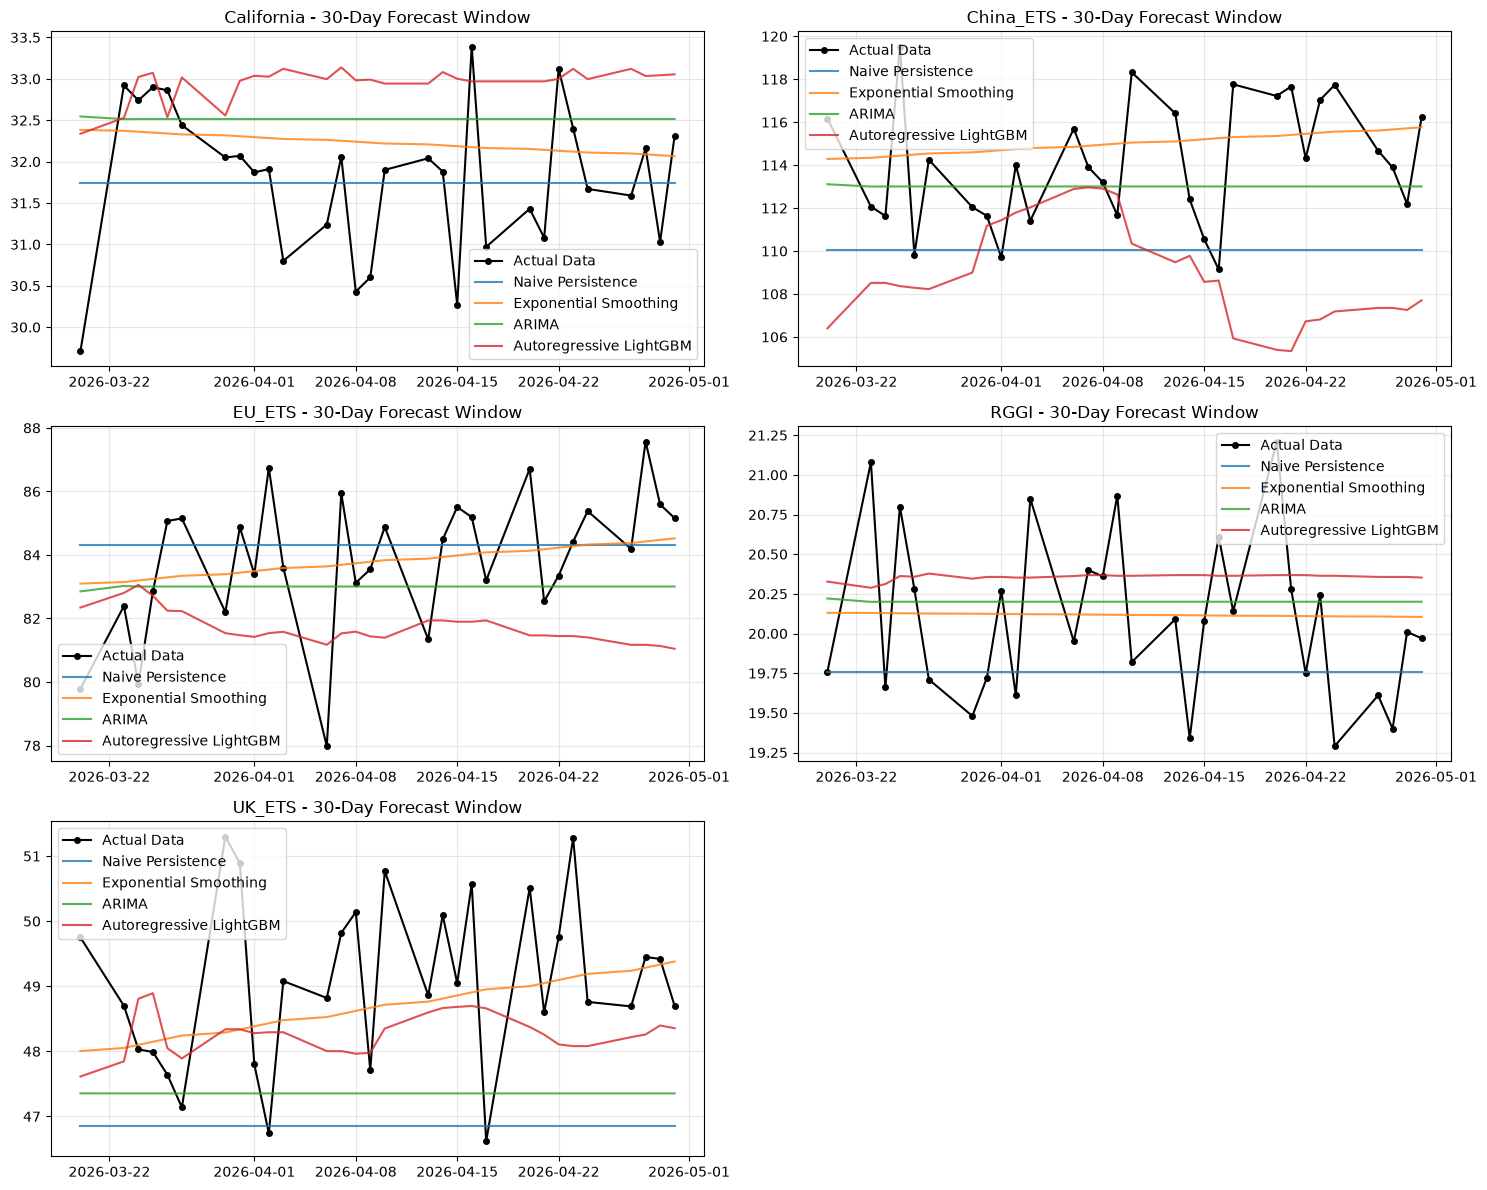

In [9]:

plt.figure(figsize=(15, 12))
for i, market in enumerate(df['market'].unique(), 1):
    plt.subplot(3, 2, i)
    m_data = final_forecast_df[final_forecast_df['market'] == market]
    
    plt.plot(m_data['date'].unique(), m_data[m_data['model_name'] == 'Autoregressive LightGBM']['actual_price'], label='Actual Data', color='black', marker='o', markersize=4)
    for model in ['Naive Persistence', 'Exponential Smoothing', 'ARIMA', 'Autoregressive LightGBM']:
        plt.plot(m_data['date'].unique(), m_data[m_data['model_name'] == model]['predicted_price'], label=model, alpha=0.8)
        
    plt.title(f"{market} - 30-Day Forecast Window")
    plt.grid(True, alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.show()
    

## 10. Conclusion and Limitations
- **Autoregressive ML (LightGBM)** is highly effective at capturing cyclicality and recent momentum, but struggles when a market undergoes an unprecedented external shock in the 30-day window due to error compound propagation.
- **ARIMA** can provide robust trending but failed on certain specific markets without dynamic differencing adjustments.
- **Naive Persistence** is notoriously difficult to beat in pure random walk financial time series, meaning complex models must justify their complexity with noticeable MAPE reductions.